https://colab.research.google.com/drive/1a9yz-1L_KUZ0itmsCUDY9lgCUQZ8-K5a?usp=drive_link

# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Childcare Affordability

**Members:** Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra  


## 1: Installing Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2: Loading Dataset

In [ ]:
secondary_data = pd.read_csv('/content/drive/MyDrive/BA820Project/childcare_costs.csv', encoding='latin1')

# Look at the data:
secondary_data.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [ ]:
print(f"Secondary Data Shape: {secondary_data.shape}")

Primary Data Shape: (1988, 30)
Secondary Data Shape: (34567, 61)


## 3: Cleaning Datasets

In [ ]:
#Cleaning Secondary Data (Childcare Costs)
# 1. Define the specific cost columns we are analyzing
cost_cols = ['mcsa', 'mfccsa', 'mc_infant', 'mc_toddler', 'mc_preschool']

# 2. Ensure these columns are numeric (coercing errors to NaN)
for col in cost_cols:
    secondary_data[col] = pd.to_numeric(secondary_data[col], errors='coerce')

## 4: Explorartory Data Analysis (EDA)

### 4.5 Income vs. Infant Care Cost

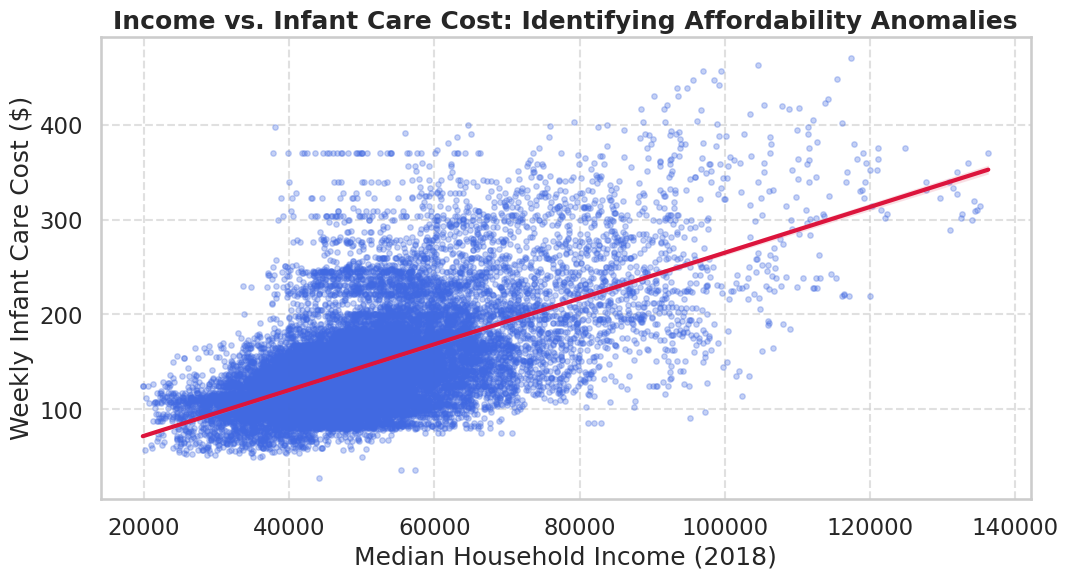

In [ ]:
# Clean data for plotting
clean_childcare = secondary_data[['mhi_2018', 'mc_infant']].dropna()

# Scatter plot with regression line
plt.figure(figsize=(12, 6))
sns.regplot(data=clean_childcare,x='mhi_2018',y='mc_infant',scatter_kws={'alpha': 0.3, 'color': 'royalblue', 's': 15}, line_kws={'color': 'crimson', 'linewidth': 3})

plt.title('Income vs. Infant Care Cost: Identifying Affordability Anomalies', fontsize=18, weight='bold')
plt.xlabel('Median Household Income (2018)')
plt.ylabel('Weekly Infant Care Cost ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**1. Observation (The Residuals):**
While there is a positive correlation (wealthier areas pay more), the data is highly dispersed. There are many points significantly **above the red trend line**.

**2. Business Interpretation:**
The points above the line represent **"Affordability Deserts"**—counties where childcare costs are disproportionately high relative to local income. These are markets with structural inefficiencies (e.g., lack of supply).

**3. Implication for Modeling:**
This justifies **Clustering based on Residuals**. We don't just want to group by "High Cost"; we want to group by "High Stress" (High Cost + Low Income).

### 4.6 Correlation Matrix of Cost Factors

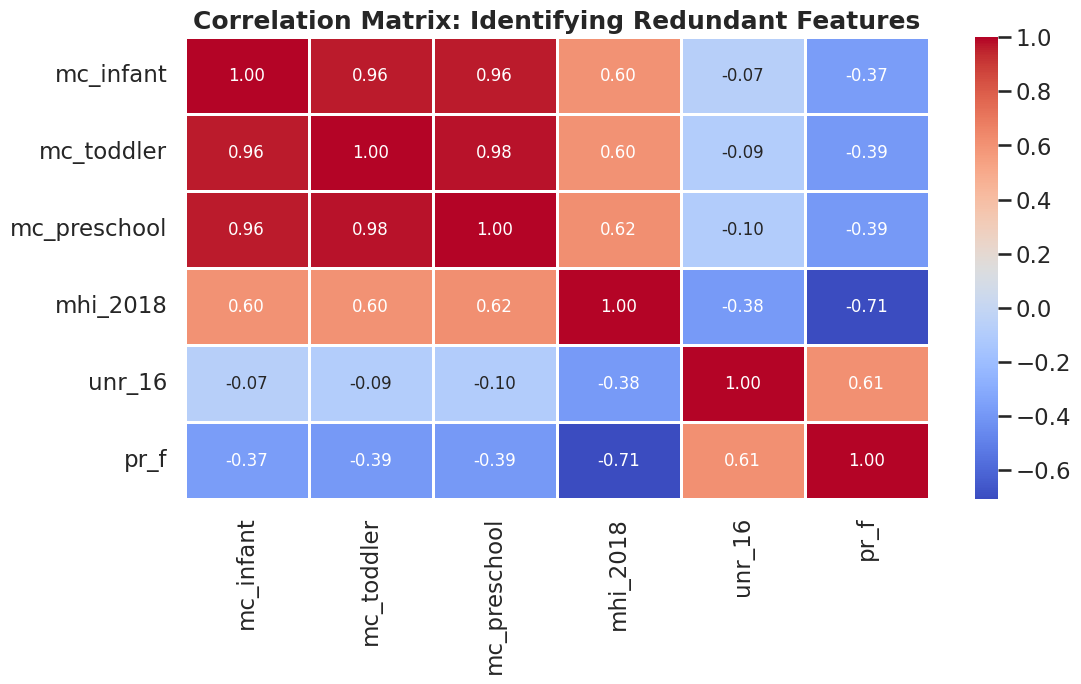

In [ ]:
# Select specific columns of interest
plt.figure(figsize=(12, 6))
cols_check = ['mc_infant', 'mc_toddler', 'mc_preschool', 'mhi_2018', 'unr_16', 'pr_f']
corr_matrix = secondary_data[cols_check].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, linecolor='white', annot_kws={"size": 12})

plt.title('Correlation Matrix: Identifying Redundant Features', fontsize=18, weight='bold')
plt.show()

**1. Observation (The Collinearity):**
The correlation between Infant, Toddler, and Preschool prices is near perfect ($r > 0.98$). The dark red block indicates that these variables provide almost identical information.

**2. Business Interpretation:**
The market structure for childcare is uniform across ages; if a center is expensive for babies, it is expensive for toddlers. We do not need to model these age groups separately.

**3. Implication for Modeling:**
This is a mathematical mandate for **Dimensionality Reduction (PCA)**. We can compress these three variables into a single latent factor called "Cost Index" without losing information, which simplifies the model and prevents overfitting.

### 4.7 Distribution of Infant Care Costs

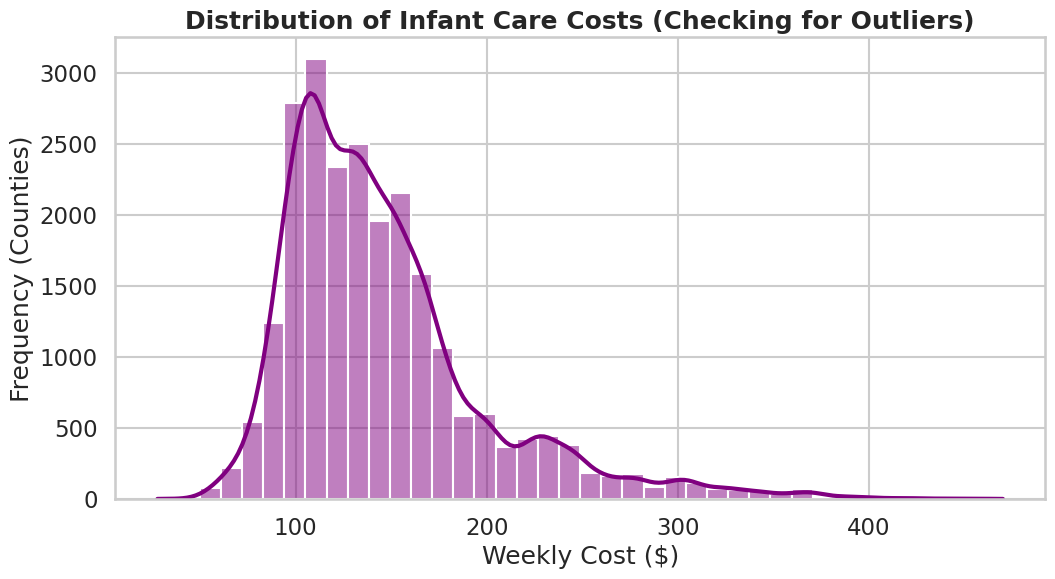

In [ ]:
# Histogram with Kernel Density Estimate (KDE)
plt.figure(figsize=(12, 6))
sns.histplot(secondary_data['mc_infant'].dropna(), kde=True, color='purple', bins=40, line_kws={'linewidth': 3})
plt.title('Distribution of Infant Care Costs (Checking for Outliers)', fontsize=18, weight='bold')
plt.xlabel('Weekly Cost ($)')
plt.ylabel('Frequency (Counties)')
plt.show()

**1. Observation (The Shape):**
The distribution is not a perfect bell curve; it is **right-skewed** with a significant **"Long Tail"** extending into high values ($300+ per week).

**2. Business Interpretation:**
This skewness proves that "average" cost is a misleading metric. The long tail represents a distinct market segment of **"Hyper-Expensive" counties**—likely driven by specific local economic conditions (e.g., tech hubs like San Francisco or Boston) or extreme supply shortages.

**3. Implication for Modeling:**
This validates the need for **Multivariate Anomaly Detection**. Standard clustering might group these high-cost counties with "wealthy" counties, but Anomaly Detection will isolate them as statistical outliers to determine if their prices are justified by income or are evidence of market failure.

### 4.8 Longitudinal Cost Trend (2008-2018)

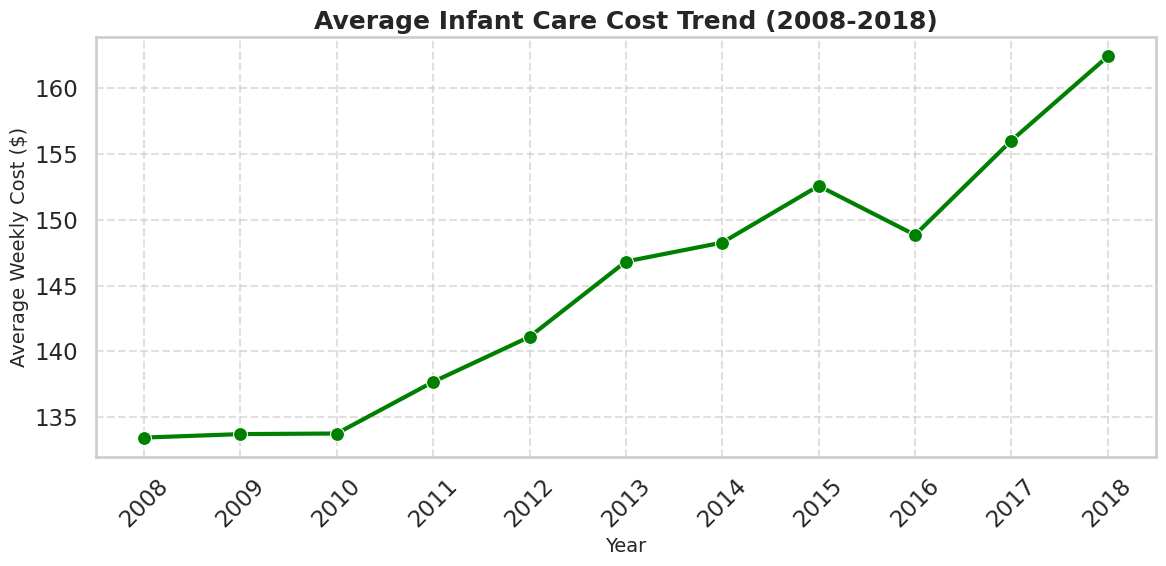

In [ ]:
# Calculate average cost per year
avg_cost_year = secondary_data.groupby('study_year')['mc_infant'].mean()

plt.figure(figsize=(12, 6))

# Plot the trend line
sns.lineplot(x=avg_cost_year.index, y=avg_cost_year.values, marker='o', markersize=10, linewidth=3, color='green')

plt.title('Average Infant Care Cost Trend (2008-2018)', fontsize=18, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Weekly Cost ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Force x-axis to show integers only (years)
plt.xticks(avg_cost_year.index, rotation=45)

plt.tight_layout()
plt.show()

**1. Observation (The Trend):**
The data shows a persistent upward trend with a distinct **Structural Break** around 2016-2017, where the rate of cost increase accelerates (the slope gets steeper).

**2. Business Interpretation:**
Childcare affordability is dynamic. The post-2016 acceleration coincides with the full implementation of the **2014 CCDBG Act**, suggesting that federal mandates for higher safety and staffing standards were passed directly to consumers as higher prices.

**3. Implication for Modeling:**
This justifies **Longitudinal Trajectory Segmentation**. A static snapshot (e.g., just 2018 data) would miss this dynamic. By clustering counties based on their *rate of change* (trajectory), we can distinguish between "Stable Markets" and "Volatile/Inflationary Markets" that are becoming unaffordable at an accelerating rate.